# genetic leakage experiment on low sample size data

In [1]:
import sys
PATH = "/scratch/aszatkow/work/projects"
sys.path.append(f"{PATH}/PRIVET")

import time

from src.misc_utils import *
from src.data_utils import *
from src.nn_utils import *
from src.stats_utils import *
from src.plot_utils import *
from src.privet import *

from metrics.AuthPct import *
from metrics.AATS import *

In [2]:
ngpu=1
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)

cuda:0


# Load data

In [3]:
PATH = "/scratch/aszatkow/work/data"
train = load_data(f"{PATH}/yri2.txt")
test = load_data(f"{PATH}/yri3.txt")
synth = load_data(f"{PATH}/yri1.txt")

In [4]:
N = train.shape[0]

train.shape, test.shape, synth.shape

((66, 33602), (66, 33602), (66, 33602))

# INITIALIZE LEAKAGE PARAMETERS

In [5]:
fake_range = np.linspace(0,0.4,31)
fake_range[0] = 0.001

copy_range = np.linspace(0,0.2,31)
copy_range[0] = 0.001

# INITIALIZE PRIVACY MAPS

In [6]:
#GLOBAL
heatmap_NPL=np.zeros((len(fake_range),len(copy_range)))

#LOCAL
tp_grid_npl = np.zeros((len(fake_range), len(copy_range)))
fp_grid_npl = np.zeros((len(fake_range), len(copy_range)))
tn_grid_npl = np.zeros((len(fake_range), len(copy_range)))
fn_grid_npl = np.zeros((len(fake_range), len(copy_range)))


# COMPUTE 1-NN distances

In [7]:
#For the fit
#Train-Train
dist_NN_tr_tr,  dist_NN_tr_tr_idx = gpu_nearest_neighbors(torch.tensor(train), k=1,distance='hamming',chunk_size=128,device=device.type,verbose=False)
p_tr_tr_NN_dist, p_tr_tr_NN_idx = sorting(dist_NN_tr_tr, dist_NN_tr_tr_idx)
p_tr_tr_NN_dist, p_tr_tr_NN_idx = np.array(p_tr_tr_NN_dist), np.array(p_tr_tr_NN_idx)

In [8]:
#Needed to construct the pseudo-synthetic data
#Synth-Train
dist_NN_syn_tr_INIT, dist_NN_syn_tr_INIT_idx = gpu_nearest_neighbors(torch.tensor(synth), torch.tensor(train), k=1,distance='hamming',chunk_size=128,device=device.type,verbose=False)
p_syn_tr_NN_dist_INIT, p_syn_tr_NN_idx_INIT = sorting(dist_NN_syn_tr_INIT, dist_NN_syn_tr_INIT_idx)
p_syn_tr_NN_dist_INIT, p_syn_tr_NN_idx_INIT = np.array(p_syn_tr_NN_dist_INIT), np.array(p_syn_tr_NN_idx_INIT)
indices_s_tr_INIT = dist_NN_syn_tr_INIT_idx.squeeze(1)

# EVT FIT CDF on Train-Train

In [9]:
partition_start = 0.01
partition_end = 0.2

start = int(np.ceil(partition_start*N)) #int(0.01*N) # if N is small start = 0 --> problem with log
end = int(partition_end*N)

#############
## Weibull ##
#############

# Fit parameters (adjust start/end indices to avoid extremes)
intercept_weibull, alpha, std_err_intercept, std_err_alpha, sigma_Y_pred, mse_weibull = fit_nearest_neighbor_cdf_weibull(p_tr_tr_NN_dist.reshape(-1,), start_idx=start, end_idx=end)

print("Weibull")
print(f"Estimated intercept = {intercept_weibull:.2f} ± {std_err_intercept:.2f}")
print(f"Estimated alpha = {alpha:.2f} ± {std_err_alpha:.2f}")
print(f"mse       = {mse_weibull:.3f}")

############
## Gumbel ##
############

intercept_gumbel, B, se_intercept, se_B, sigma_pred, mse_gumbel = fit_nearest_neighbor_cdf_gumbel(p_tr_tr_NN_dist.reshape(-1,), start, end)

print("Gumbel")
print(f"Intercept = {intercept_gumbel:.3f} ± {se_intercept:.3f}")
print(f"B         = {B:.3f} ± {se_B:.3f}")
print(f"mse       = {mse_gumbel:.3f}")

Weibull
Estimated intercept = -461.14 ± 44.21
Estimated alpha = 51.85 ± 5.00
mse       = 0.036
Gumbel
Intercept = -54.538 ± 5.028
B         = 0.007 ± 0.001
mse       = 0.035


In [14]:
if mse_gumbel < mse_weibull:
    label_best_fit = "Gumbel"
    param1 = intercept_gumbel
    param2 = B
else:
    label_best_fit = "Weibull"
    param1 = intercept_weibull
    param2 = alpha
    
print(f"{label_best_fit} fit")

Gumbel fit


# RUNNER for PRIVET

### FILL PRIVACY MAPS

In [11]:
threshold = -3

#train_torch = torch.tensor(train, dtype = torch.float32)
#test_torch = torch.tensor(test, dtype = torch.float32)

In [15]:
start = time.time()
time_lst_privet, time_lst_auth, time_lst_aats = [], [], []
for i,f_fake in enumerate(fake_range):
    print(f_fake)
    n = int(np.ceil(N*f_fake))
    flist=np.zeros((N,)).astype(bool) #this is the groundtruth
    flist[:n]=True
    for j,f_copy in enumerate(copy_range):

        fake = generate_fake_synth(train, synth, indices_s_tr_INIT, f_fake=f_fake, f_copy=f_copy)

        start_i_j = time.time()
        store_in_mat, p_syn_tr_NN_dist, p_syn_te_NN_dist = PRIVET(torch.tensor(train), torch.tensor(test), torch.tensor(fake), param1, param2, label_best_fit, renormalization = None, distance='hamming', device=device.type, groundtruth = flist)
        end_i_j = time.time()
        time_lst_privet.append(end_i_j-start_i_j)

        delta_pi = store_in_mat[:,0]
        flist_bis = store_in_mat[:,-1].astype(bool)

        NPL = delta_pi<=threshold

        tp_npl, fn_npl, fp_npl, tn_npl = get_predictions(NPL, flist_bis)

        heatmap_NPL[i,j] = NPL.sum()

        tp_grid_npl[i, j] = tp_npl
        fp_grid_npl[i, j] = fp_npl
        tn_grid_npl[i, j] = tn_npl
        fn_grid_npl[i, j] = fn_npl
        
        if j%10==0:
            print(rf"Δπ f_fake={f_fake}, f_copy={f_copy}, tp={tp_npl}, fp={fp_npl}, tn={tn_npl}, fn={fn_npl}")
            
        
        del fake

0.001
Δπ f_fake=0.001, f_copy=0.001, tp=0, fp=0, tn=65, fn=1
Δπ f_fake=0.001, f_copy=0.06666666666666667, tp=0, fp=0, tn=65, fn=1
Δπ f_fake=0.001, f_copy=0.13333333333333333, tp=0, fp=0, tn=65, fn=1
Δπ f_fake=0.001, f_copy=0.2, tp=1, fp=0, tn=65, fn=0
0.013333333333333334
Δπ f_fake=0.013333333333333334, f_copy=0.001, tp=0, fp=0, tn=65, fn=1
Δπ f_fake=0.013333333333333334, f_copy=0.06666666666666667, tp=0, fp=0, tn=65, fn=1
Δπ f_fake=0.013333333333333334, f_copy=0.13333333333333333, tp=0, fp=0, tn=65, fn=1
Δπ f_fake=0.013333333333333334, f_copy=0.2, tp=1, fp=0, tn=65, fn=0
0.02666666666666667
Δπ f_fake=0.02666666666666667, f_copy=0.001, tp=0, fp=0, tn=64, fn=2
Δπ f_fake=0.02666666666666667, f_copy=0.06666666666666667, tp=0, fp=0, tn=64, fn=2
Δπ f_fake=0.02666666666666667, f_copy=0.13333333333333333, tp=1, fp=0, tn=64, fn=1
Δπ f_fake=0.02666666666666667, f_copy=0.2, tp=2, fp=0, tn=64, fn=0
0.04
Δπ f_fake=0.04, f_copy=0.001, tp=0, fp=0, tn=63, fn=3
Δπ f_fake=0.04, f_copy=0.066666666666666

In [16]:
rounding = 4

print(f"PRIVET execution time: average={np.round(np.mean(time_lst_privet),rounding)}s, std={np.round(np.std(time_lst_privet),rounding)}")


PRIVET execution time: average=0.0555s, std=0.0009


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

D_paths = {"PRIVET (NPL)" : heatmap_NPL
}

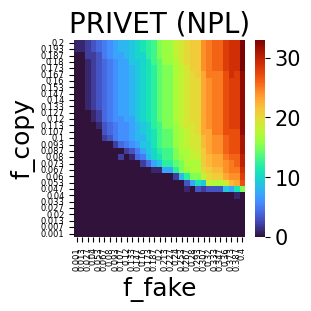

In [24]:
import seaborn as sns


N = 66

plt.rcParams.update({
    'axes.labelsize': 18,    # x and y labels
    'axes.titlesize': 20,    # subplot titles
    'xtick.labelsize': 6,   # x-axis ticks
    'ytick.labelsize': 6    # y-axis ticks
})

fig, ax = plt.subplots(1, 1, figsize=(3, 3), constrained_layout=True,dpi=100)
titles = list(D_paths)
data_grids = [D_paths[path] for path in D_paths]

data = data_grids[0] 
title = titles[0]
cmap="turbo"
#if title == "Gen. gap FLD" or title == r"$C_T$" or title == r"PRIVET ($\Delta \pi$)" : cmap="turbo_r"
im = sns.heatmap(data.T, xticklabels=np.round(fake_range, 3), yticklabels=np.round(copy_range, 3), 
                 annot=False, cmap=cmap, ax=ax, cbar=True)
ax.invert_yaxis()  # Ensure increasing order from bottom to top
ax.set_xlabel("f_fake")
ax.set_ylabel("f_copy")
ax.set_title(title)

    # Access the colorbar and set its label size
cbar = im.collections[0].colorbar
if cbar:
    cbar.ax.tick_params(labelsize=15)  # Set colorbar tick label size
        # If you also want to change the colorbar title size:
        # cbar.set_label('Your Label', size=30)

#fig.tight_layout()
#fig.savefig("../FIG/simulated_SNPs_all_force_good_groundtruth_paper_fig.png", 
#            dpi=fig.dpi, bbox_inches='tight')
plt.show()

In [26]:
den_p = tp_grid_npl + fp_grid_npl
den_r = tp_grid_npl + fn_grid_npl

# pre-allocate result arrays full of your “default” (e.g. 0.0)
precision_npl = np.zeros_like(tp_grid_npl, dtype=float)
recall_npl    = np.zeros_like(tp_grid_npl, dtype=float)

# do the division only where denominator ≠ 0
np.divide(tp_grid_npl,
          den_p,
          out=precision_npl,
          where=den_p != 0)

np.divide(tp_grid_npl,
          den_r,
          out=recall_npl,
          where=den_r != 0)


array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.        ,
        1.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
      

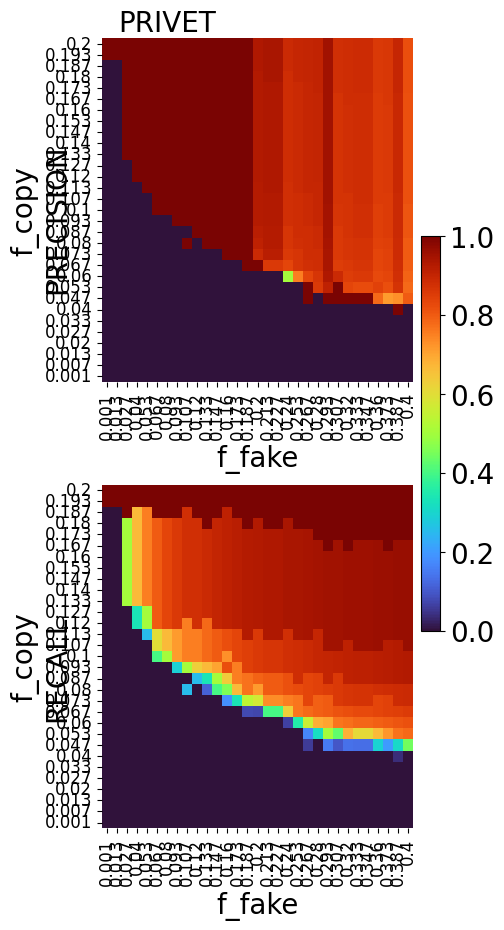

In [30]:
fake_range = np.linspace(0,0.4,31)
fake_range[0] = 0.001

copy_range = np.linspace(0,0.2,31)
copy_range[0] = 0.001
FONTSIZE = 20
plt.rcParams.update({
    'axes.labelsize': FONTSIZE,
    'axes.titlesize': FONTSIZE,
    'xtick.labelsize': FONTSIZE-8,
    'ytick.labelsize': FONTSIZE-8
})

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(5, 10), constrained_layout=False, dpi=100)
# we’ll manage spacing manually
fig.subplots_adjust(top=0.90, left=0.15, wspace=0.3, hspace=0.3)

data_grids = [precision_npl, recall_npl]
# Shared color limits
vmin, vmax = 0, 1

# Plot heatmaps without titles
for ax, data in zip(axes.flat, data_grids):
    im = sns.heatmap(
        data.T,
        xticklabels=np.round(fake_range, 3),
        yticklabels=np.round(copy_range, 3),
        annot=False,
        cmap="turbo",
        ax=ax,
        cbar=False,
        vmin=vmin,
        vmax=vmax
    )
    ax.invert_yaxis()
    ax.set_xlabel("f_fake")
    ax.set_ylabel("f_copy")

# Single colorbar
cbar = fig.colorbar(im.collections[0], ax=axes.ravel().tolist(),
                    shrink=0.5, pad=0.02)
cbar.ax.tick_params(labelsize=FONTSIZE)

# Column labels
fig.text(0.28, 0.915, "PRIVET", ha='center', va='center', fontsize=FONTSIZE)
#fig.text(0.63, 0.915, "In-Authenticity",    ha='center', va='center', fontsize=FONTSIZE)

# Row labels (rotated)
fig.text(0.06, 0.72, "PRECISION",     ha='center', va='center',
         rotation='vertical', fontsize=FONTSIZE)
fig.text(0.06, 0.27, "RECALL",  ha='center', va='center',
         rotation='vertical', fontsize=FONTSIZE)

plt.show()


In [25]:
tp_grid_groundtruth = np.zeros((len(fake_range), len(copy_range)))
fp_grid_groundtruth = np.zeros((len(fake_range), len(copy_range)))
tn_grid_groundtruth = np.zeros((len(fake_range), len(copy_range)))
fn_grid_groundtruth = np.zeros((len(fake_range), len(copy_range)))

##################################
###FILL GROUNDTRUTH PRIVACY MAP###
##################################
N_max = int(np.ceil(N*0.4))

for i,f_fake in enumerate(fake_range):
    verolage = int(np.ceil(N*f_fake))
    tp_grid_groundtruth[i] = np.ones((1,len(copy_range)))*verolage
    fp_grid_groundtruth[i] = np.ones((1,len(copy_range)))*0
    tn_grid_groundtruth[i] = np.ones((1,len(copy_range)))*(N-verolage)
    fn_grid_groundtruth[i] = np.ones((1,len(copy_range)))*0

#plt.rcParams.update({'font.size': 15})
plt.rcParams.update({
    'axes.labelsize': 22,    # x and y labels
    'axes.titlesize': 25,    # subplot titles
    'xtick.labelsize': 20,   # x-axis ticks
    'ytick.labelsize': 20    # y-axis ticks
})

# Create subplots
fig, axes = plt.subplots(3, 4, figsize=(40, 26), constrained_layout=True,dpi=300)
titles = ["TP (GROUNDTRUTH)", "FP (GROUNDTRUTH)", "TN (GROUNDTRUTH)", "FN (GROUNDTRUTH)", "TP (NPL)", "FP (NPL)", "TN (NPL)", "FN (NPL)", "TP (In-Auth)", "FP (In-Auth)", "TN (In-Auth)", "FN (In-Auth)"]
data_grids = [tp_grid_groundtruth/N, fp_grid_groundtruth/N, tn_grid_groundtruth/N, fn_grid_groundtruth/N, tp_grid_npl/N, fp_grid_npl/N, tn_grid_npl/N, fn_grid_npl/N, tp_grid_authen/N, fp_grid_authen/N, tn_grid_authen/N, fn_grid_authen/N]

# Create a single color scale
vmin, vmax = 0, 1#int(np.ceil(N*0.4))

# Loop through subplots and plot heatmaps
for ax, data, title in zip(axes.flat, data_grids, titles):
    #if title=="FP (GROUNDTRUTH)" or title=="FN (GROUNDTRUTH)":continue
    im = sns.heatmap(data.T, xticklabels=np.round(fake_range, 3), yticklabels=np.round(copy_range, 3), 
                     annot=False, cmap="turbo", ax=ax, cbar=False, vmin=vmin, vmax=vmax)
    ax.invert_yaxis()  # Ensure increasing order from bottom to top
    ax.set_xlabel("f_fake")
    ax.set_ylabel("f_copy")
    ax.set_title(title)


# Add a single colorbar using the last heatmap's mappable
cbar = fig.colorbar(im.collections[0], ax=axes.ravel().tolist(), shrink=0.5, pad=0.02)
cbar.ax.tick_params(labelsize=26)  # Adjust size as needed (e.g., 16, 18, etc.)

plt.show()

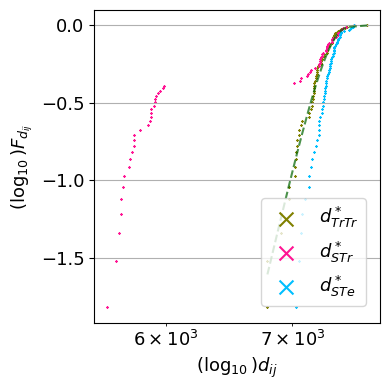

In [21]:
styles = [{'color': 'olive', 'label': r'$d^*_{TrTr}$', 'marker': 'x', 's': 1},
          {'color': 'deeppink', 'label': r'$d^*_{STr}$', 'marker': 'x', 's': 1},
          {'color': 'deepskyblue', 'label': r'$d^*_{STe}$', 'marker': 'x', 's': 1}]

fig, ax, FONTSIZE = plot_CDFs(p_tr_tr_NN_dist, p_syn_tr_NN_dist, styles, p_syn_te=p_syn_te_NN_dist)

#if Weibull fit (TODO: handles other fit)
label_fit = "Weibull"
x = p_tr_tr_NN_dist.reshape(-1,).astype(np.float64)
Y_pred_log10 = np.log10(1-np.exp(-np.exp(intercept)*x**alpha))

ax.plot(p_tr_tr_NN_dist, Y_pred_log10, color='darkgreen', label=label_fit, linestyle="dashed", alpha=.7)
ax.set_ylim([np.log10(1/train.shape[0])-0.1,0.1])
plt.show()